In [1]:
import pandas as pd
from datapreparation.data_preparation import Data_Preparation as dp
prep = dp()
X = prep.prepare_data_general_v2
X

,mac_id,PumpTimeInSeconds,WaterLevel,hours_since_watering,soil_deficit_ratio,deficit_x_light,deficit_x_temp,deficit_x_air,et_approx
0,0,0.00,89.35,0.0,-0.007826,-0.002786,0.003209,0.018313,195.476829
1,12,0.00,86.83,0.0,0.005470,NaN,-0.003774,-0.012198,NaN
2,10,0.00,86.12,0.0,0.003130,0.000423,0.001409,-0.001377,225.217602
3,5,0.00,99.02,0.0,-0.018497,-0.011265,0.025526,0.032000,790.036223
4,6,0.00,90.73,0.0,0.001893,0.000580,-0.001250,-0.007081,205.738271
...,...,...,...,...,...,...,...,...,...
134276,11,7.21,56.42,156.0,0.374447,-0.805810,-0.670260,-0.116079,6.906311
134277,1,6.71,23.52,21.0,0.275149,NaN,-0.349439,-0.148581,NaN
134278,12,5.42,55.33,86.0,0.199829,-0.548930,-0.553526,-0.839282,0.000000
134279,0,5.71,59.51,60.0,0.193391,-0.511133,-0.187590,-0.518289,2.641856


In [2]:
y = X['PumpTimeInSeconds']
X = X.drop(columns=['PumpTimeInSeconds','WaterLevel'])
y

0         0.00
1         0.00
2         0.00
3         0.00
4         0.00
          ... 
134276    7.21
134277    6.71
134278    5.42
134279    5.71
134280    6.29
Name: PumpTimeInSeconds, Length: 134281, dtype: float64

<Figure size 900x500 with 0 Axes>

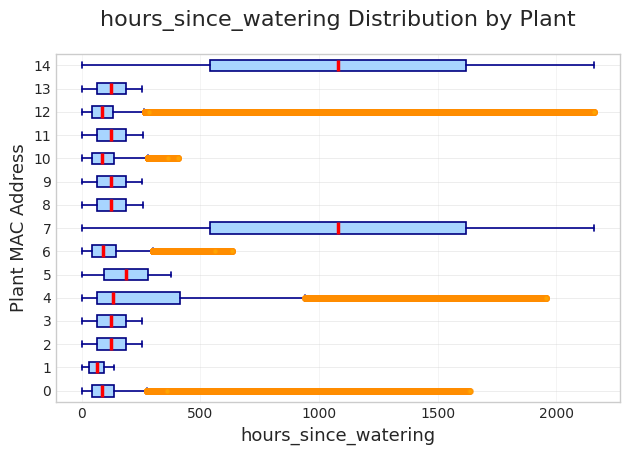

<Figure size 900x500 with 0 Axes>

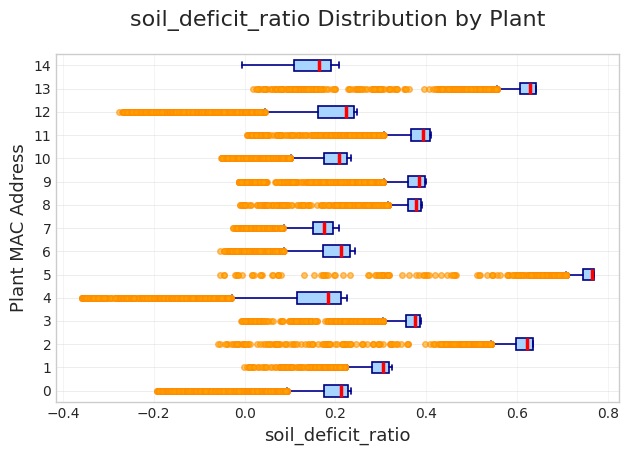

<Figure size 900x500 with 0 Axes>

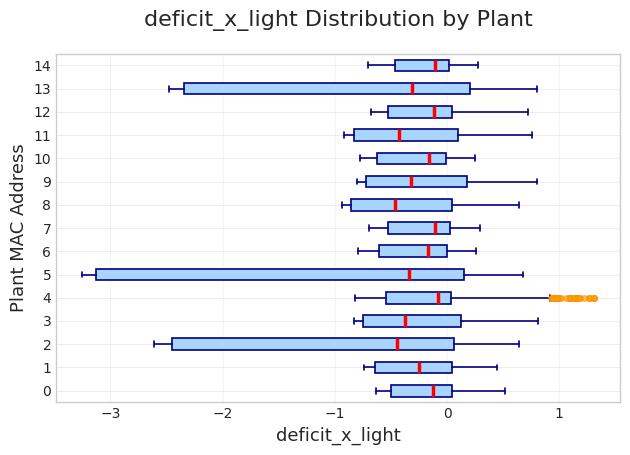

<Figure size 900x500 with 0 Axes>

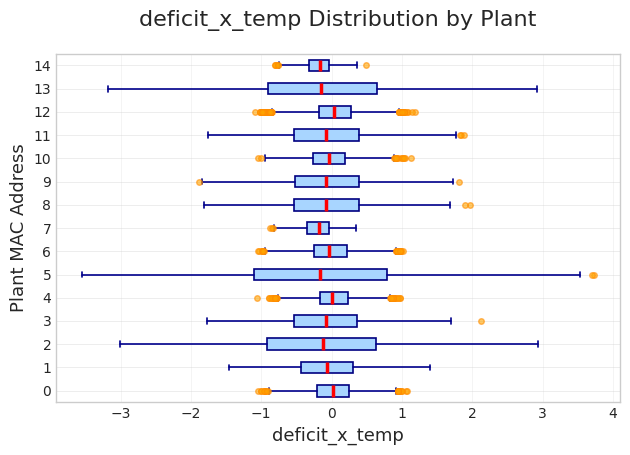

<Figure size 900x500 with 0 Axes>

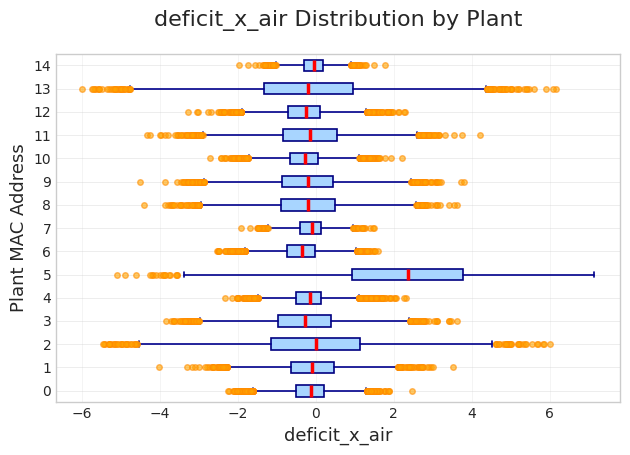

<Figure size 900x500 with 0 Axes>

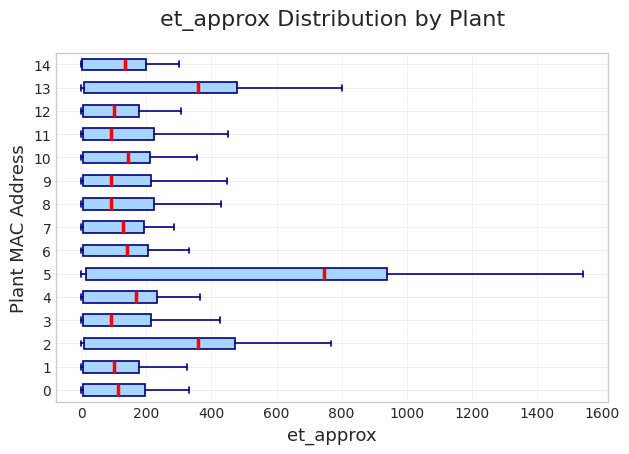

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = X.select_dtypes(include='number').columns.drop("mac_id")
plt.style.use('seaborn-v0_8-whitegrid')

for col in numeric_cols:

    plt.figure(figsize=(9, 5))

    X.boxplot(
        column=col,
        by='mac_id',
        vert=False,
        patch_artist=True,

        # Box styling
        boxprops=dict(
            facecolor='#a8d5ff',
            edgecolor='navy',
            linewidth=1.2
        ),

        # Median line
        medianprops=dict(
            color='red',
            linewidth=2.5
        ),

        # Whiskers
        whiskerprops=dict(
            color='darkblue',
            linewidth=1.2
        ),

        # Caps
        capprops=dict(
            color='darkblue',
            linewidth=1.2
        ),

        # Outliers
        flierprops=dict(
            marker='o',
            markerfacecolor='orange',
            markeredgecolor='darkorange',
            markersize=4,
            alpha=0.6
        )
    )

    plt.title(f"{col} Distribution by Plant", fontsize=16, pad=20)
    plt.suptitle("")

    plt.xlabel(col, fontsize=13)
    plt.ylabel("Plant MAC Address", fontsize=13)

    plt.xticks(rotation=0)

    plt.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

In [4]:
# import numpy as np
# # transform feature that are right-skewed
# X["et_approx"] = X["et_approx"].apply(lambda x: np.log1p(x))
#
# # Optional: nicer style
# plt.style.use('seaborn-v0_8-whitegrid')
#
# # Create the figure
# plt.figure(figsize=(7, 5))
#
# X.boxplot(
#     column='et_approx',
#     by='mac_id',
#     vert=False,
#     patch_artist=True,
#     boxprops=dict(facecolor='#a8d5ff', edgecolor='navy', linewidth=1.2),
#     medianprops=dict(color='red', linewidth=2.5),
#     whiskerprops=dict(color='darkblue'),
#     capprops=dict(color='darkblue'),
#     flierprops=dict(marker='o', markerfacecolor='orange', markersize=4, alpha=0.6)
# )
#
# plt.title("et_approx Distribution by Plant", fontsize=16, pad=20)
# plt.suptitle("")
# plt.xlabel("et_approx", fontsize=13)
# plt.ylabel("Plant MAC Address", fontsize=13)
#
#
# plt.xticks(rotation=0)
# plt.grid(axis='x', alpha=0.3)
#
# ax = plt.gca()
# plt.tight_layout()
# plt.show()

## Splitting the data

In [5]:
X_train, X_val, X_test, y_train, y_val, y_test = prep.train_val_test_split_64_16_20(func = prep.prepare_data_pump_time_v2)
X_train

,hours_since_watering,soil_deficit_ratio,deficit_x_light,deficit_x_temp,deficit_x_air,et_approx
4105,273.0,0.768786,-3.230439,NaN,-2.429364,NaN
2730,182.0,0.091826,NaN,-0.247012,-0.604216,NaN
84024,83.0,0.562348,-2.303659,-0.073105,1.591445,0.714663
106895,133.0,0.182957,-0.054430,-0.064035,-0.934908,5.175905
8842,589.0,-0.017949,0.049188,0.052231,0.068026,0.283182
...,...,...,...,...,...,...
62835,219.0,0.341353,-0.661372,0.314045,-0.559820,2.006201
90812,2.0,0.220000,-0.397760,0.096800,-0.358600,4.092834
74102,31.0,0.216772,-0.281912,0.567943,0.351171,5.128716
75779,206.0,NaN,NaN,NaN,NaN,5.392630


In [6]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5, weights='distance')

X_train_imputed = imputer.fit_transform(X_train)

X_train_imputed = pd.DataFrame(
    X_train_imputed,
    columns=X_train.columns,
    index=X_train.index
)

In [7]:
# X_train_imputed

### interpolation trial (tries to follow the time series)

In [8]:
# X_train_imputed, X_val_imputed, X_test_imputed, y_train, y_val, y_test = prep.train_val_test_split_64_16_20(
#      func=prep.prepare_data_pump_time_v3
#  )

## Impute the val and test data using transform

In [9]:
X_val_imputed = imputer.transform(X_val)
X_test_imputed = imputer.transform(X_test)

X_val_imputed = pd.DataFrame(
    X_val_imputed,
    columns=X_val.columns,
    index=X_val.index
)
X_test_imputed = pd.DataFrame(
    X_test_imputed,
    columns=X_test.columns,
    index=X_test.index
)
X_test_imputed

,hours_since_watering,soil_deficit_ratio,deficit_x_light,deficit_x_temp,deficit_x_air,et_approx
20928,135.0,0.394486,0.268251,-0.114401,-0.311644,5.400998
107419,117.0,0.305249,-0.047691,-0.423905,-0.911429,2.691243
41278,71.0,0.406634,-0.910453,-0.378170,-0.618084,0.000000
119396,32.0,0.398496,0.569850,0.187293,1.056015,5.750309
78091,75.0,0.199051,-0.707326,-0.007962,-0.494449,3.000649
...,...,...,...,...,...,...
31193,63.0,0.398496,-0.802173,-0.932481,-0.195263,0.000000
111514,331.0,0.172348,-0.571333,-0.475680,-0.243010,0.000000
66845,69.0,0.208696,-0.347947,0.252522,0.298435,1.801856
119041,6.0,0.360660,-0.373644,-0.490733,-0.567485,5.434638


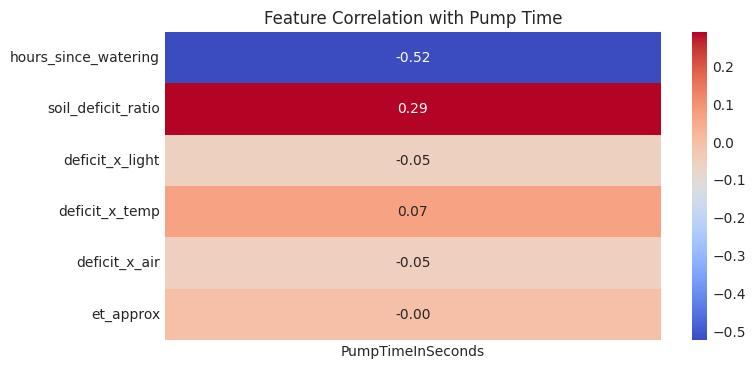

In [10]:

from sklearn.metrics import confusion_matrix, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt

# correlation of each feature with target
corr_series = X_train.corrwith(y_train)

plt.figure(figsize=(8, 4))
sns.heatmap(corr_series.to_frame(name='PumpTimeInSeconds'),
            annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation with Pump Time')
plt.show()

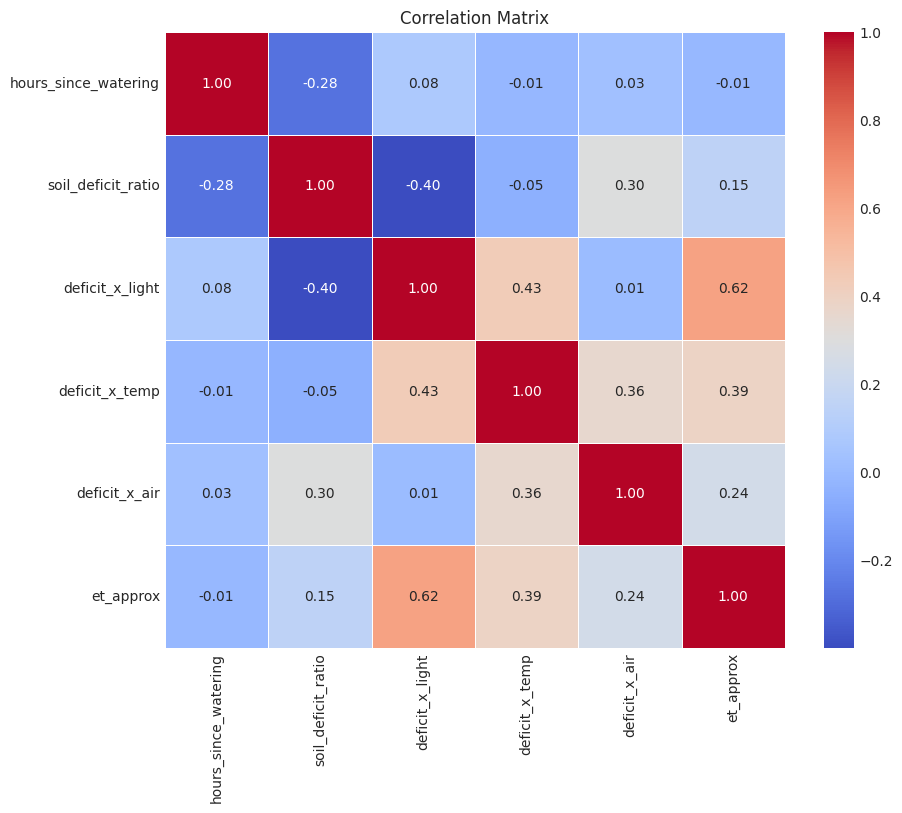

In [11]:
corr = X_train.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix")
plt.show()

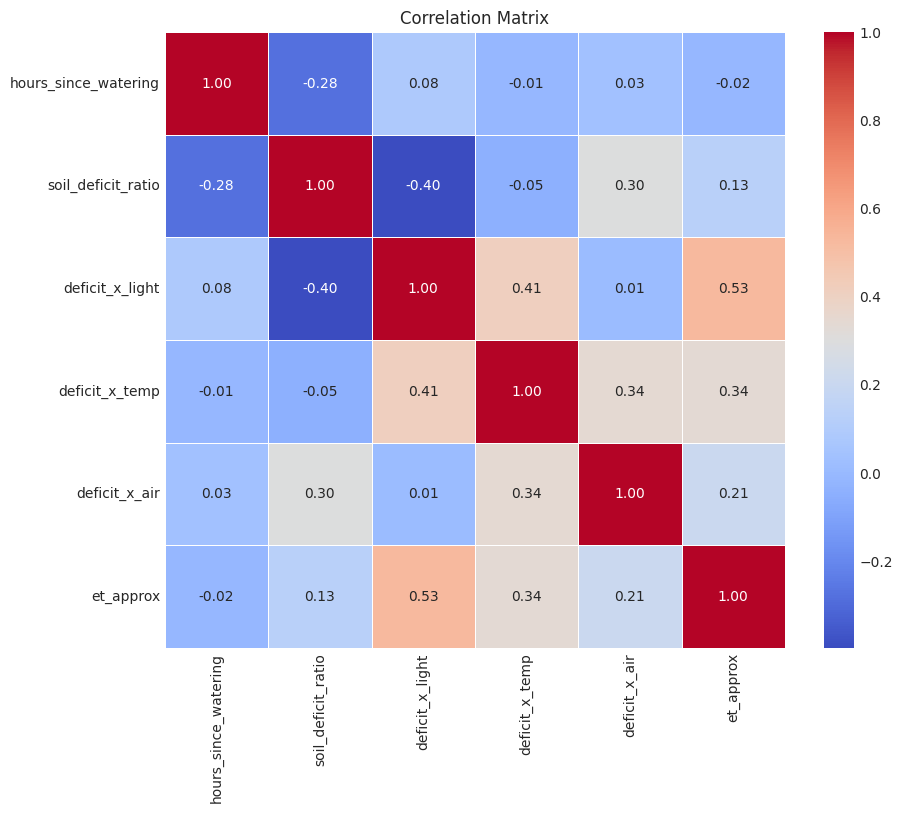

In [12]:
## Update feature engineering to fix the 99% corr
# X_train_imputed = X_train_imputed.drop(columns=['soil_deficit'])
# X_val_imputed = X_val_imputed.drop(columns=['soil_deficit'])
# X_test_imputed = X_test_imputed.drop(columns=['soil_deficit'])

# Drop high corr

# X_train_imputed = X_train_imputed.drop(columns=['deficit_x_light'])
# X_val_imputed = X_val_imputed.drop(columns=['deficit_x_light'])
# X_test_imputed = X_test_imputed.drop(columns=['deficit_x_light'])
# X_train_imputed = X_train_imputed.drop(columns=['hours_since_watering'])
# X_val_imputed = X_val_imputed.drop(columns=['hours_since_watering'])
# X_test_imputed = X_test_imputed.drop(columns=['hours_since_watering'])
corr = X_train_imputed.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix")
plt.show()

In [13]:
import xgboost as xgb
import optuna
from optuna.integration import XGBoostPruningCallback


dtrain = xgb.DMatrix(X_train_imputed, label=y_train)
dval = xgb.DMatrix(X_val_imputed, label=y_val)
dtest = xgb.DMatrix(X_test_imputed, label=y_test)

def objective(trial):
    params = {
        "objective": "reg:squarederror",
        "eval_metric": "mae",
        "tree_method": "hist",
        "device": "cuda",

        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "min_child_weight": trial.suggest_int("min_child_weight", 2, 20),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "subsample": trial.suggest_float("subsample", 0.7, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 0.9),

        "reg_alpha": trial.suggest_float("reg_alpha", 0.1, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 10.0),

        "seed": 42,
    }

    pruning_callback = XGBoostPruningCallback(trial, "val-mae")

    evals_result = {}

    model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=5000,
        evals=[(dval, "val")],
        early_stopping_rounds=100,
        verbose_eval=False,
        callbacks=[pruning_callback],
        evals_result=evals_result
    )

    val_mae = model.best_score

    trial.set_user_attr("best_num_boost_round", model.best_iteration + 1)

    return val_mae


study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=50)
)

study.optimize(objective, n_trials=40, show_progress_bar=True)

best_params = study.best_params
best_num_boost_round = study.best_trial.user_attrs["best_num_boost_round"]

best_params.update({
    "objective": "reg:squarederror",
    "eval_metric": "mae",
    "tree_method": "hist",
    "device": "cuda",
    "seed": 42,
})

final_model = xgb.train(
    params=best_params,
    dtrain=dtrain,
    num_boost_round=best_num_boost_round,
    evals=[(dval, "val")],
    verbose_eval=False
)

[I 2026-05-14 11:32:37,951] A new study created in memory with name: no-name-fc178b3c-01d2-4adf-a6bb-442b32f522bb


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-05-14 11:32:43,602] Trial 0 finished with value: 0.8043559426562458 and parameters: {'max_depth': 5, 'min_child_weight': 18, 'learning_rate': 0.01160362748766698, 'subsample': 0.7475186299160885, 'colsample_bytree': 0.7871588695462894, 'reg_alpha': 1.1997147858709687, 'reg_lambda': 0.8705011932966081, 'gamma': 0.08968992733756176}. Best is trial 0 with value: 0.8043559426562458.
[I 2026-05-14 11:32:45,087] Trial 1 finished with value: 0.8351087017458271 and parameters: {'max_depth': 5, 'min_child_weight': 19, 'learning_rate': 0.02947915306224484, 'subsample': 0.8602597699100565, 'colsample_bytree': 0.81417228517291, 'reg_alpha': 3.4475801167093842, 'reg_lambda': 1.4109042905334879, 'gamma': 8.87989158920358}. Best is trial 0 with value: 0.8043559426562458.
[I 2026-05-14 11:32:47,627] Trial 2 finished with value: 0.8351027201065147 and parameters: {'max_depth': 3, 'min_child_weight': 17, 'learning_rate': 0.032449484473355134, 'subsample': 0.8420218324271374, 'colsample_bytree': 

In [14]:
# import numpy as np
# import xgboost as xgb
# import optuna
# from optuna.integration import XGBoostPruningCallback
#
# # ─────────────────────────────────────────────────────────────
# # DMatrix
# # ─────────────────────────────────────────────────────────────
# dtrain = xgb.DMatrix(X_train_imputed, label=y_train)
# dval   = xgb.DMatrix(X_val_imputed,   label=y_val)
# dtest  = xgb.DMatrix(X_test_imputed,  label=y_test)
#
#
# # ─────────────────────────────────────────────────────────────
# # TAU — the single knob that controls overwater tolerance
# #
# #   tau = 0.70  →  model targets the 70th percentile
# #              →  ~30% of predictions will exceed true value
# #              →  ~70% will be below (underwatering preferred)
# #
# #   Why pinball instead of asymmetric quadratic (alpha)?
# #     - alpha had no interpretable meaning; tau does.
# #     - Quadratic gradients explode on large errors with high alpha.
# #     - Pinball gradient is bounded (always in [-1, 0] or [0, 1] range
# #       before weighting), so training is stable by construction.
# #     - Quantile regression is theoretically sound; the model converges
# #       to exactly the tau-th quantile of the conditional distribution.
# # ─────────────────────────────────────────────────────────────
# TAU = 0.70   # Start here. Raise toward 0.80 if overwater is still too common.
#              # Lower toward 0.60 if 30% overwater is still too many.
#
#
# # ─────────────────────────────────────────────────────────────
# # 1.  PINBALL (QUANTILE) OBJECTIVE
# # ─────────────────────────────────────────────────────────────
# def pinball_objective(y_pred, dtrain):
#     """
#     Pinball loss at quantile TAU.
#
#     Loss per sample:
#         err > 0  (overwater):   L = tau       * err
#         err < 0  (underwater):  L = (tau - 1) * err   →  positive (it's a loss)
#
#     Gradient (dL/d_pred):
#         err > 0:   tau
#         err < 0:   tau - 1   (negative number, e.g. -0.30 for tau=0.70)
#
#     Hessian:
#         Constant 1 everywhere — no explosion, no instability.
#     """
#     y_true = dtrain.get_label()
#     err    = y_pred - y_true
#
#     grad = np.where(err >= 0, 0.65, 0.65 - 1.0)   # always in (-1, 1)
#     hess = np.ones_like(err)                     # flat, stable
#
#     return grad, hess
#
#
# # ─────────────────────────────────────────────────────────────
# # 2.  PINBALL METRIC  (Optuna minimises this)
# #
# #   Using the same loss as the objective keeps training and
# #   hyperparameter selection perfectly aligned.
# # ─────────────────────────────────────────────────────────────
# def pinball_metric(y_pred, dtrain):
#     """
#     Mean pinball loss — lower is better.
#     Optuna minimises this, so trial selection matches training goal.
#     """
#     y_true = dtrain.get_label()
#     err    = y_pred - y_true
#     loss   = np.where(err >= 0, TAU * err, (TAU - 1.0) * err)
#     return "pinball", float(np.mean(loss))
#
#
# # ─────────────────────────────────────────────────────────────
# # 3.  OPTUNA OBJECTIVE
# # ─────────────────────────────────────────────────────────────
# def objective(trial):
#     params = {
#         "tree_method": "hist",
#         "device":      "cuda",
#         "monotone_constraints": (1, 1, 1),
#         "seed": 42,
#
#         # ── Hyperparameters ──────────────────────────────────
#         "max_depth":          trial.suggest_int("max_depth", 3, 6),
#         "min_child_weight":   trial.suggest_int("min_child_weight", 1, 20),
#         "learning_rate":      trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
#         "subsample":          trial.suggest_float("subsample",      0.6, 0.9),
#         "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.6, 0.9),
#         "reg_alpha":          trial.suggest_float("reg_alpha",  0.1, 50.0, log=True),
#         "reg_lambda":         trial.suggest_float("reg_lambda", 0.1, 50.0, log=True),
#     }
#
#     pruning_callback = XGBoostPruningCallback(trial, "val-pinball")
#     evals_result     = {}
#
#     model = xgb.train(
#         params                = params,
#         dtrain                = dtrain,
#         obj                   = pinball_objective,
#         custom_metric         = pinball_metric,
#         num_boost_round       = 2000,
#         evals                 = [(dtrain, "train"), (dval, "val")],
#         early_stopping_rounds = 50,
#         verbose_eval          = False,
#         callbacks             = [pruning_callback],
#         evals_result          = evals_result,
#     )
#
#     best_iter    = model.best_iteration
#     val_pinball  = evals_result["val"]["pinball"][best_iter]
#
#     # ── Per-trial diagnostics ─────────────────────────────────
#     val_preds  = model.predict(dval)
#     y_val_true = dval.get_label()
#     err        = val_preds - y_val_true
#
#     ow_mask = err > 0
#     ow_rate = float(np.mean(ow_mask))
#     ow_mae  = float(np.mean(np.abs(err[ow_mask]))) if ow_mask.any() else 0.0
#     uw_mae  = float(np.mean(np.abs(err[~ow_mask]))) if (~ow_mask).any() else 0.0
#
#     trial.set_user_attr("best_num_boost_round", best_iter + 1)
#     trial.set_user_attr("overwater_rate",        ow_rate)
#     trial.set_user_attr("overwater_mae",         ow_mae)
#     trial.set_user_attr("underwater_mae",        uw_mae)
#     trial.set_user_attr("plain_mae", float(np.mean(np.abs(err))))
#
#     return val_pinball
#
#
# # ─────────────────────────────────────────────────────────────
# # 4.  RUN STUDY
# # ─────────────────────────────────────────────────────────────
# study = optuna.create_study(
#     direction  = "minimize",
#     study_name = f"xgb_pinball_tau{TAU}",
#     sampler    = optuna.samplers.TPESampler(seed=42),
# )
#
# study.optimize(objective, n_trials=50, show_progress_bar=True)
#
#
# # ─────────────────────────────────────────────────────────────
# # 5.  REPORT
# # ─────────────────────────────────────────────────────────────
# bt = study.best_trial
# print(f"\n── Best Trial  (TAU = {TAU}) ────────────────────────────")
# print(f"  Pinball loss    : {bt.value:.4f}")
# print(f"  Plain MAE       : {bt.user_attrs['plain_mae']:.4f}")
# print(f"  Overwater rate  : {bt.user_attrs['overwater_rate']:.1%}  (target ≈ {1-TAU:.0%})")
# print(f"  Overwater MAE   : {bt.user_attrs['overwater_mae']:.4f}")
# print(f"  Underwater MAE  : {bt.user_attrs['underwater_mae']:.4f}")
# print(f"  Boost rounds    : {bt.user_attrs['best_num_boost_round']}")
# print(f"  Params          : {bt.params}")
#
#
# # ─────────────────────────────────────────────────────────────
# # 6.  FINAL TRAINING
# # ─────────────────────────────────────────────────────────────
# best_params = {
#     **study.best_params,
#     "tree_method":          "hist",
#     "device":               "cuda",
#     "seed":                 42,
# }
#
# final_model = xgb.train(
#     params          = best_params,
#     dtrain          = dtrain,
#     obj             = pinball_objective,
#     custom_metric   = pinball_metric,
#     num_boost_round = bt.user_attrs["best_num_boost_round"],
#     evals           = [(dval, "val")],
# )

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# evaluate
preds_val = final_model.predict(dval)
preds_test = final_model.predict(dtest)

print(f"\nBest params: {best_params}")
print(f"\nVal  MAE: {mean_absolute_error(y_val, preds_val):.3f}")
print(f"Val  MSE: {mean_squared_error(y_val, preds_val):.3f}")
print(f"Val  R²:  {r2_score(y_val, preds_val):.4f}")
print(f"\nTest MAE: {mean_absolute_error(y_test, preds_test):.3f}")
print(f"Test MSE: {mean_squared_error(y_test, preds_test):.3f}")
print(f"Test R²:  {r2_score(y_test, preds_test):.4f}")
import os
# Delete old model before training
if os.path.exists("/workspace/models/pump-time/xgb_pump_time_regretion_model.ubj"):
    os.remove("/workspace/models/pump-time/xgb_pump_time_regretion_model.ubj")
    print("Old model deleted")

final_model.save_model("/workspace/models/pump-time/xgb_pump_time_regretion_model.ubj")
print("\nModel saved.")


Best params: {'max_depth': 7, 'min_child_weight': 7, 'learning_rate': 0.06399921650727515, 'subsample': 0.7907016282149848, 'colsample_bytree': 0.847269642648112, 'reg_alpha': 3.2835839482978733, 'reg_lambda': 0.18854501455549827, 'gamma': 0.679541933831681, 'objective': 'reg:squarederror', 'eval_metric': 'mae', 'tree_method': 'hist', 'device': 'cuda', 'seed': 42}

Val  MAE: 0.788
Val  MSE: 1.369
Val  R²:  0.6387

Test MAE: 0.795
Test MSE: 1.392
Test R²:  0.6381
Old model deleted

Model saved.
